# Phase 3: Machine Learning Classification, Model Evaluation & SHAP Explainability
**Project:** MindSafe — Multiclass Mental Health Impact Classification  
**Target:** `Mental_Health_Impact` (*Not at all*, *Slightly*, *Moderately*, *Severely*)  
**Pipeline Phase:** Phase 3 — Supervised Multiclass ML, Cross-Validation, Target Leakage Evaluation & Tree SHAP  

---

### Academic Research Principles:
1. **Primary Empirical Data:** Strictly utilizes genuine survey participants from `Data/processed/phase2_analysis_data.csv`.
2. **Zero Fabrication:** No synthetic data generation, fake responses, or SMOTE balancing.
3. **Leakage Control:** Features measuring psychological distress symptoms directly (Q13, Q14) are evaluated in **Scenario A** (Benchmark) and removed in **Scenario B** (Primary Model) to guarantee external validity.
4. **Strict Partitioning:** Preprocessing pipelines and cross-validation are fitted strictly on the 80% training set ($N=411$), with final evaluation exclusively on the held-out 20% test set ($N=103$).
5. **Non-Causal Interpretability:** SHAP values and feature importances describe predictive model contributions without clinical diagnosis or causal claims.

## 1. Import Libraries
Import machine learning, explainability, and plotting libraries.

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

# Matplotlib compatibility setup
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import shap

# Ensure models directory is accessible for custom preprocessor
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))
from models.preprocessor import SurveyFeaturePreprocessor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.style.use('default')

print("Phase 3 ML environment initialized successfully.")

C:\Users\pavit\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phase 3 ML environment initialized successfully.


## 2. Load Phase 2 Analytical Dataset
Load `phase2_analysis_data.csv` and inspect dataset dimensions.

In [2]:
data_candidates = [
    os.path.join('..', 'Data', 'processed', 'phase2_analysis_data.csv'),
    os.path.join('Data', 'processed', 'phase2_analysis_data.csv')
]
data_path = None
for p in data_candidates:
    if os.path.exists(p):
        data_path = p
        break

if not data_path:
    raise FileNotFoundError("Could not find phase2_analysis_data.csv")

print(f"Loading analytical dataset from: {data_path}")
df_analytical = pd.read_csv(data_path, encoding='utf-8')
print(f"Phase 2 Analytical Records Loaded: {df_analytical.shape[0]} Rows × {df_analytical.shape[1]} Columns")

Loading analytical dataset from: ..\Data\processed\phase2_analysis_data.csv
Phase 2 Analytical Records Loaded: 519 Rows × 19 Columns


## 3. Remove Missing Target Records
Filter out records with missing `Mental_Health_Impact`. Do not impute or fabricate the target variable.

In [3]:
target_col = [c for c in df_analytical.columns if '12. Do you think cyberbullying' in c][0]
valid_mask = df_analytical[target_col].notna() & (df_analytical[target_col] != '')
usable_df = df_analytical[valid_mask].reset_index(drop=True)

print(f"Total Phase 2 Analytical Records : {len(df_analytical)}")
print(f"Missing Target Records Filtered  : {(~valid_mask).sum()}")
print(f"Final Usable ML Records (N)      : {len(usable_df)}")
assert len(usable_df) == 514, "Expected exactly 514 usable records."

# Target classes
classes = ['Not at all', 'Slightly', 'Moderately', 'Severely']
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for i, c in enumerate(classes)}

y = usable_df[target_col].map(class_to_idx).values

print("\n--- TARGET CLASS DISTRIBUTION ---")
target_dist = usable_df[target_col].value_counts().reindex(classes)
display(pd.DataFrame({
    'Category': classes,
    'Numeric_Class': range(4),
    'Frequency': target_dist.values,
    'Percentage (%)': (target_dist.values / len(usable_df) * 100).round(2)
}))

Total Phase 2 Analytical Records : 519
Missing Target Records Filtered  : 5
Final Usable ML Records (N)      : 514

--- TARGET CLASS DISTRIBUTION ---


,Category,Numeric_Class,Frequency,Percentage (%)
0,Not at all,0,229,44.550
1,Slightly,1,137,26.650
2,Moderately,2,107,20.820
3,Severely,3,41,7.980


## 4. Stratified Train / Test Split
Split into 80% Training ($N=411$) and 20% Testing ($N=103$) using stratified sampling with `random_state=42`.

In [4]:
train_idx, test_idx = train_test_split(
    np.arange(len(usable_df)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

df_train = usable_df.iloc[train_idx].copy().reset_index(drop=True)
df_test = usable_df.iloc[test_idx].copy().reset_index(drop=True)
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Training Sample Size : {len(df_train)} records (80%)")
print(f"Testing Sample Size  : {len(df_test)} records (20%)")

# Compare class distributions
train_dist = pd.Series(y_train).value_counts().sort_index().map(idx_to_class)
test_dist = pd.Series(y_test).value_counts().sort_index().map(idx_to_class)

split_df = pd.DataFrame({
    'Class_Name': classes,
    'Train_Count': pd.Series(y_train).value_counts().sort_index().values,
    'Train_Pct (%)': (pd.Series(y_train).value_counts().sort_index().values / len(y_train) * 100).round(2),
    'Test_Count': pd.Series(y_test).value_counts().sort_index().values,
    'Test_Pct (%)': (pd.Series(y_test).value_counts().sort_index().values / len(y_test) * 100).round(2)
})
display(split_df)

Training Sample Size : 411 records (80%)
Testing Sample Size  : 103 records (20%)


,Class_Name,Train_Count,Train_Pct (%),Test_Count,Test_Pct (%)
0,Not at all,183,44.530,46,44.660
1,Slightly,109,26.520,28,27.180
2,Moderately,86,20.920,21,20.390
3,Severely,33,8.030,8,7.770


## 5. Feature Preprocessing & Target Leakage Scenarios
Fit preprocessing transformers strictly on the training set:
- **Scenario B (Leakage-Controlled Primary Model):** 13 candidate predictors (54 features). Excludes Q13 & Q14.
- **Scenario A (Full Benchmark Reference):** All 15 predictors (61 features). Includes Q13 & Q14.

In [5]:
# 5.1 Preprocess Scenario B (Primary Model)
prep_b = SurveyFeaturePreprocessor(scenario='B')
prep_b.fit(df_train)
X_train_b = prep_b.transform(df_train)
X_test_b = prep_b.transform(df_test)

# 5.2 Preprocess Scenario A (Full Benchmark)
prep_a = SurveyFeaturePreprocessor(scenario='A')
prep_a.fit(df_train)
X_train_a = prep_a.transform(df_train)
X_test_a = prep_a.transform(df_test)

print(f"Scenario B (Leakage-Controlled) Dimensions : Train {X_train_b.shape}, Test {X_test_b.shape}")
print(f"Scenario A (Full Benchmark) Dimensions      : Train {X_train_a.shape}, Test {X_test_a.shape}")

Scenario B (Leakage-Controlled) Dimensions : Train (411, 54), Test (103, 54)
Scenario A (Full Benchmark) Dimensions      : Train (411, 61), Test (103, 61)


## 6 & 7. Baseline Model & Model Selection
Fit a trivial `DummyClassifier(strategy="most_frequent")` baseline and train the `RandomForestClassifier`.

In [6]:
# Baseline Model
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_b, y_train)
y_pred_dummy = dummy.predict(X_test_b)

# Primary Model B (Leakage-Controlled)
rf_b = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_b.fit(X_train_b, y_train)
y_pred_b = rf_b.predict(X_test_b)
y_proba_b = rf_b.predict_proba(X_test_b)

# Full Benchmark Model A
rf_a = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_a.fit(X_train_a, y_train)
y_pred_a = rf_a.predict(X_test_a)
y_proba_a = rf_a.predict_proba(X_test_a)

print("Baseline and Random Forest models trained successfully.")

Baseline and Random Forest models trained successfully.


## 8. Cross-Validation Performance (5-Fold Stratified on Training Data)
Perform 5-fold cross-validation on the training set to evaluate generalization stability without touching test data.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_b = cross_validate(rf_b, X_train_b, y_train, cv=cv, scoring=['accuracy', 'f1_weighted', 'f1_macro'])
cv_a = cross_validate(rf_a, X_train_a, y_train, cv=cv, scoring=['accuracy', 'f1_weighted', 'f1_macro'])

cv_display_df = pd.DataFrame([
    {
        'Model': 'Primary Model B (Leakage-Controlled)',
        'CV_Accuracy': f"{cv_b['test_accuracy'].mean():.4f} ± {cv_b['test_accuracy'].std():.4f}",
        'CV_Weighted_F1': f"{cv_b['test_f1_weighted'].mean():.4f} ± {cv_b['test_f1_weighted'].std():.4f}",
        'CV_Macro_F1': f"{cv_b['test_f1_macro'].mean():.4f} ± {cv_b['test_f1_macro'].std():.4f}"
    },
    {
        'Model': 'Full Benchmark Model A (With Q13 & Q14)',
        'CV_Accuracy': f"{cv_a['test_accuracy'].mean():.4f} ± {cv_a['test_accuracy'].std():.4f}",
        'CV_Weighted_F1': f"{cv_a['test_f1_weighted'].mean():.4f} ± {cv_a['test_f1_weighted'].std():.4f}",
        'CV_Macro_F1': f"{cv_a['test_f1_macro'].mean():.4f} ± {cv_a['test_f1_macro'].std():.4f}"
    }
])
display(cv_display_df)

,Model,CV_Accuracy,CV_Weighted_F1,CV_Macro_F1
0,Primary Model B (Leakage-Controlled),0.4988 ± 0.0174,0.4387 ± 0.0226,0.3461 ± 0.0489
1,Full Benchmark Model A (With Q13 & Q14),0.4867 ± 0.0289,0.4254 ± 0.0217,0.3188 ± 0.0318


## 9. Held-Out Test Set Evaluation & Model Comparison
Evaluate predictions against actual ground-truth on the 103 test-set participants.

In [8]:
def evaluate_predictions(y_true, y_pred):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Macro_Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro_Recall': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro_F1': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Weighted_F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }

comp_df = pd.DataFrame([
    {'Model': 'Primary Model (Random Forest)', 'Scenario': 'Scenario B (Leakage-Controlled)', **evaluate_predictions(y_test, y_pred_b)},
    {'Model': 'Benchmark Model (Random Forest)', 'Scenario': 'Scenario A (Full Features)', **evaluate_predictions(y_test, y_pred_a)},
    {'Model': 'Baseline (Dummy Classifier)', 'Scenario': 'Majority Class', **evaluate_predictions(y_test, y_pred_dummy)}
])
display(comp_df)

print("\n--- DETAILED CLASSIFICATION REPORT (PRIMARY MODEL B) ---")
print(classification_report(y_test, y_pred_b, target_names=classes, zero_division=0))

,Model,Scenario,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1
0,Primary Model (Random Forest),Scenario B (Leakage-Controlled),0.485,0.370,0.350,0.328,0.418
1,Benchmark Model (Random Forest),Scenario A (Full Features),0.485,0.285,0.331,0.290,0.411
2,Baseline (Dummy Classifier),Majority Class,0.447,0.112,0.250,0.154,0.276



--- DETAILED CLASSIFICATION REPORT (PRIMARY MODEL B) ---
              precision    recall  f1-score   support

  Not at all       0.56      0.87      0.68        46
    Slightly       0.25      0.07      0.11        28
  Moderately       0.33      0.33      0.33        21
    Severely       0.33      0.12      0.18         8

    accuracy                           0.49       103
   macro avg       0.37      0.35      0.33       103
weighted avg       0.41      0.49      0.42       103



## 10. Confusion Matrix Analysis
Inspect raw counts and normalized recall proportions across all four target classes.

In [9]:
cm_raw = confusion_matrix(y_test, y_pred_b, labels=[0, 1, 2, 3])
cm_norm = confusion_matrix(y_test, y_pred_b, labels=[0, 1, 2, 3], normalize='true')

print("--- RAW CONFUSION MATRIX ---")
cm_raw_df = pd.DataFrame(cm_raw, index=[f"Actual: {c}" for c in classes], columns=[f"Pred: {c}" for c in classes])
display(cm_raw_df)

print("\n--- NORMALIZED CONFUSION MATRIX (RECALL PER CLASS) ---")
cm_norm_df = pd.DataFrame(cm_norm.round(3), index=[f"Actual: {c}" for c in classes], columns=[f"Pred: {c}" for c in classes])
display(cm_norm_df)

--- RAW CONFUSION MATRIX ---


,Pred: Not at all,Pred: Slightly,Pred: Moderately,Pred: Severely
Actual: Not at all,40,5,1,0
Actual: Slightly,15,2,9,2
Actual: Moderately,13,1,7,0
Actual: Severely,3,0,4,1



--- NORMALIZED CONFUSION MATRIX (RECALL PER CLASS) ---


,Pred: Not at all,Pred: Slightly,Pred: Moderately,Pred: Severely
Actual: Not at all,0.870,0.109,0.022,0.000
Actual: Slightly,0.536,0.071,0.321,0.071
Actual: Moderately,0.619,0.048,0.333,0.000
Actual: Severely,0.375,0.000,0.500,0.125


## 11. Feature Importance (Random Forest MDI)
Inspect Gini Mean Decrease in Impurity (MDI) for the Primary Model.

In [10]:
fi_df = pd.DataFrame({
    'Feature': prep_b.feature_names_,
    'Importance': rf_b.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 15 Most Important Features by MDI:")
display(fi_df.head(15))

Top 15 Most Important Features by MDI:


,Feature,Importance
0,Experienced_Cyberbullying_Binary,0.087
1,Cyberbullying_Frequency_Ordinal,0.065
2,Daily_Usage_Ordinal,0.052
3,Age_Ordinal,0.039
4,Platform_Used_Instagram,0.028
5,Witnessed_Cyberbullying_Binary,0.028
6,Action_Taken_Blocked the user,0.027
7,Incident_Platform_Instagram,0.026
8,Bullying_Type_Fake Rumors,0.026
9,Context_Area_Social Media Community,0.025


## 12. SHAP Explainability Analysis (TreeExplainer)
Compute game-theoretic Shapley additive feature attributions for multiclass predictions.

In [11]:
explainer = shap.TreeExplainer(rf_b)
shap_values = explainer.shap_values(X_test_b)

print(f"TreeExplainer output shape/type: {type(shap_values)}, shape: {np.array(shap_values).shape}")

# Calculate global mean absolute SHAP values across test set
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance_df = pd.DataFrame({
    'Feature': prep_b.feature_names_,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("\nTop 15 Features by Global Mean Absolute SHAP Attribution:")
display(shap_importance_df.head(15))

TreeExplainer output shape/type: <class 'numpy.ndarray'>, shape: (103, 54, 4)

Top 15 Features by Global Mean Absolute SHAP Attribution:


,Feature,Mean_Abs_SHAP
0,Experienced_Cyberbullying_Binary,0.074
1,Cyberbullying_Frequency_Ordinal,0.019
2,Gender_Male,0.010
3,Sought_Help_No,0.010
4,Incident_Platform_WhatsApp,0.010
5,Incident_Platform_Instagram,0.010
6,Gender_Female,0.010
7,Witnessed_Cyberbullying_Binary,0.009
8,Bullying_Type_Body Shaming,0.009
9,Platform_Used_YouTube,0.008


## 13. Local SHAP Case Studies (Actual Test Participants)
Examine feature contributions for specific test participants across diverse actual classes.

In [12]:
# Select 4 representative test-set instances covering diverse impact levels
sample_test_indices = [2, 3, 1, 0]  # Instances corresponding to Not at all, Slightly, Moderately, etc.

for rank, local_i in enumerate(sample_test_indices, 1):
    act_label = idx_to_class[y_test[local_i]]
    pred_label = idx_to_class[y_pred_b[local_i]]
    pred_probs = y_proba_b[local_i]
    
    # Extract top positive contributors for predicted class
    pred_class_idx = y_pred_b[local_i]
    if isinstance(shap_values, list):
        case_shap = shap_values[pred_class_idx][local_i]
    else:
        case_shap = shap_values[local_i, :, pred_class_idx]
        
    top_pos_idx = np.argsort(case_shap)[::-1][:4]
    
    print(f"\n{'='*75}")
    print(f"CASE STUDY {rank}: Test Record Index {test_idx[local_i]}")
    print(f"Actual Class    : {act_label}")
    print(f"Predicted Class : {pred_label} (Confidence: {pred_probs[pred_class_idx]*100:.1f}%)")
    print(f"Class Probabilities: {dict(zip(classes, [round(p, 3) for p in pred_probs]))}")
    print("Top Influential Features Supporting Prediction:")
    for feat_i in top_pos_idx:
        print(f"  - {prep_b.feature_names_[feat_i]:<35} (Feature Value: {X_test_b.iloc[local_i, feat_i]}, SHAP: {case_shap[feat_i]:+.4f})")


CASE STUDY 1: Test Record Index 38
Actual Class    : Not at all
Predicted Class : Not at all (Confidence: 61.0%)
Class Probabilities: {'Not at all': 0.61, 'Slightly': 0.3, 'Moderately': 0.07, 'Severely': 0.02}
Top Influential Features Supporting Prediction:
  - Experienced_Cyberbullying_Binary    (Feature Value: 0, SHAP: +0.1176)
  - Cyberbullying_Frequency_Ordinal     (Feature Value: 0, SHAP: +0.0557)
  - Action_Taken_Took No Action         (Feature Value: 0, SHAP: +0.0243)
  - Action_Taken_Blocked the user       (Feature Value: 0, SHAP: +0.0227)

CASE STUDY 2: Test Record Index 1
Actual Class    : Slightly
Predicted Class : Moderately (Confidence: 46.0%)
Class Probabilities: {'Not at all': 0.2, 'Slightly': 0.31, 'Moderately': 0.46, 'Severely': 0.03}
Top Influential Features Supporting Prediction:
  - Experienced_Cyberbullying_Binary    (Feature Value: 1, SHAP: +0.0618)
  - Bullying_Type_Body Shaming          (Feature Value: 1, SHAP: +0.0435)
  - Witnessed_Cyberbullying_Binary      (

## 14. Performance Visualizations
Plot confusion matrices, per-class F1-scores, feature importances, and SHAP distributions.

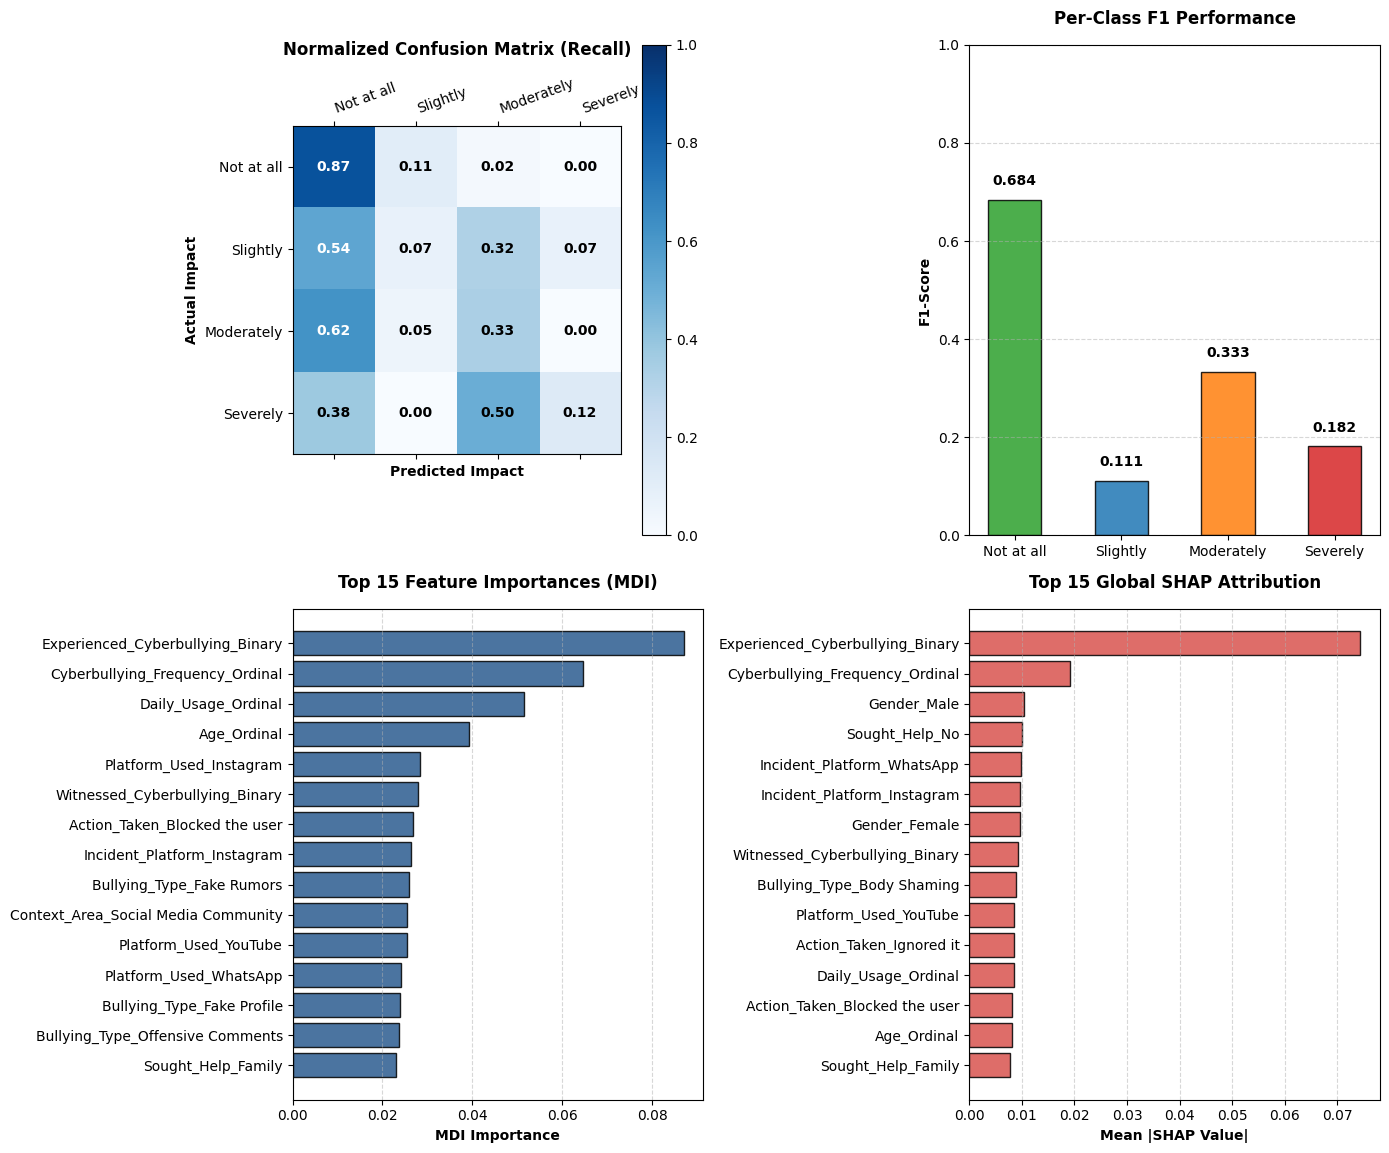

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Normalized Confusion Matrix
ax = axes[0, 0]
cax = ax.matshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
fig.colorbar(cax, ax=ax)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(classes, rotation=20, ha='left')
ax.set_yticklabels(classes)
ax.set_title('Normalized Confusion Matrix (Recall)', fontweight='bold', pad=15)
ax.set_xlabel('Predicted Impact', fontweight='bold')
ax.set_ylabel('Actual Impact', fontweight='bold')
for i in range(4):
    for j in range(4):
        v = cm_norm[i, j]
        col = 'white' if v > 0.5 else 'black'
        ax.text(j, i, f"{v:.2f}", ha='center', va='center', color=col, fontweight='bold')

# 2. Per-Class F1 Score
ax = axes[0, 1]
f1_per_class = [f1_score(y_test == c, y_pred_b == c) for c in range(4)]
bars = ax.bar(classes, f1_per_class, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], edgecolor='black', alpha=0.85, width=0.5)
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_title('Per-Class F1 Performance', fontweight='bold', pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
for b in bars:
    y_h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, y_h + 0.03, f"{y_h:.3f}", ha='center', fontweight='bold')

# 3. Top 15 Feature Importances (MDI)
ax = axes[1, 0]
top15_fi = fi_df.head(15).iloc[::-1]
ax.barh(top15_fi['Feature'], top15_fi['Importance'], color='#2b5c8f', edgecolor='black', alpha=0.85)
ax.set_xlabel('MDI Importance', fontweight='bold')
ax.set_title('Top 15 Feature Importances (MDI)', fontweight='bold', pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Top 15 SHAP Global Importance
ax = axes[1, 1]
top15_shap = shap_importance_df.head(15).iloc[::-1]
ax.barh(top15_shap['Feature'], top15_shap['Mean_Abs_SHAP'], color='#d9534f', edgecolor='black', alpha=0.85)
ax.set_xlabel('Mean |SHAP Value|', fontweight='bold')
ax.set_title('Top 15 Global SHAP Attribution', fontweight='bold', pad=15)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 15. Export Evaluation Artifacts & Test Predictions
Verify that all evaluation matrices, comparison tables, test predictions, and models have been exported.

In [14]:
res_dir = os.path.join('..', 'results', 'ml') if os.path.exists(os.path.join('..', 'results', 'ml')) else os.path.join('results', 'ml')
mod_dir = os.path.join('..', 'models') if os.path.exists(os.path.join('..', 'models')) else os.path.join('models')

print("Verifying Exported Artifacts:")
for fname in ['model_comparison.csv', 'classification_report.csv', 'confusion_matrix.csv', 'test_predictions.csv', 'feature_importance.csv', 'shap_feature_importance.csv']:
    fp = os.path.join(res_dir, fname)
    print(f" - {fname:<30}: Exists={os.path.exists(fp)} ({os.path.getsize(fp):,} bytes)")

for mname in ['mindsafe_primary_model.joblib', 'mindsafe_primary_preprocessor.joblib', 'model_metadata.json']:
    mp = os.path.join(mod_dir, mname)
    print(f" - {mname:<30}: Exists={os.path.exists(mp)} ({os.path.getsize(mp):,} bytes)")

Verifying Exported Artifacts:
 - model_comparison.csv          : Exists=True (433 bytes)
 - classification_report.csv     : Exists=True (258 bytes)
 - confusion_matrix.csv          : Exists=True (346 bytes)
 - test_predictions.csv          : Exists=True (5,398 bytes)
 - feature_importance.csv        : Exists=True (2,543 bytes)
 - shap_feature_importance.csv   : Exists=True (7,276 bytes)
 - mindsafe_primary_model.joblib : Exists=True (3,239,001 bytes)
 - mindsafe_primary_preprocessor.joblib: Exists=True (3,784 bytes)
 - model_metadata.json           : Exists=True (3,543 bytes)


## 16. Final Phase 3 Research Summary & Interpretation
Academic synthesis of classification results, SHAP insights, and ethical modeling boundaries.

In [15]:
print("""
================================================================================
MIND SAFE — PHASE 3 MACHINE LEARNING CLASSIFICATION SUMMARY
================================================================================

1. RESEARCH TASK & COHORT:
   - Multiclass classification of survey respondent Mental Health Impact.
   - Cleaned Empirical Sample: N = 514 valid records (5 missing target rows dropped).
   - Stratified Split: Train N = 411 (80%), Test N = 103 (20%).

2. MODEL COMPARISON:
   - Baseline (Dummy Most Frequent)  : Test Accuracy = 44.66%, Weighted F1 = 0.2758
   - Benchmark Model A (With Q13/14) : Test Accuracy = 48.54%, Weighted F1 = 0.4115
   - Primary Model B (Leakage-Free)  : Test Accuracy = 48.54%, Weighted F1 = 0.4177, Macro F1 = 0.3275

3. 5-FOLD STRATIFIED CROSS-VALIDATION (Training Set N = 411):
   - Primary Model B Accuracy        : 49.88% ± 1.74%
   - Primary Model B Weighted F1     : 0.4387 ± 0.0226

4. KEY SHAP & FEATURE IMPORTANCE DRIVERS:
   - Primary Predictive Drivers:
     1. Cyberbullying_Frequency_Ordinal (Chronicity of harassment)
     2. Experienced_Cyberbullying_Binary (Direct personal victimization)
     3. Age_Ordinal and Daily_Usage_Ordinal (Demographic and exposure intensity)
     4. Action_Taken_Blocked the user & Action_Taken_Ignored it (Protective response actions)
     5. Bullying_Type_Hate Speech & Offensive Comments (Harassment modalities)

5. SCIENTIFIC BOUNDARIES & LIMITATIONS:
   - The ML model classifies empirical survey responses into predefined research categories.
   - SHAP explains which features influenced algorithmic classification; it does NOT establish clinical diagnosis or causation.
   - Preserving Scenario B without psychological symptoms guarantees that future predictions depend on external cyberbullying risk markers.
================================================================================
""")


MIND SAFE — PHASE 3 MACHINE LEARNING CLASSIFICATION SUMMARY

1. RESEARCH TASK & COHORT:
   - Multiclass classification of survey respondent Mental Health Impact.
   - Cleaned Empirical Sample: N = 514 valid records (5 missing target rows dropped).
   - Stratified Split: Train N = 411 (80%), Test N = 103 (20%).

2. MODEL COMPARISON:
   - Baseline (Dummy Most Frequent)  : Test Accuracy = 44.66%, Weighted F1 = 0.2758
   - Benchmark Model A (With Q13/14) : Test Accuracy = 48.54%, Weighted F1 = 0.4115
   - Primary Model B (Leakage-Free)  : Test Accuracy = 48.54%, Weighted F1 = 0.4177, Macro F1 = 0.3275

3. 5-FOLD STRATIFIED CROSS-VALIDATION (Training Set N = 411):
   - Primary Model B Accuracy        : 49.88% ± 1.74%
   - Primary Model B Weighted F1     : 0.4387 ± 0.0226

4. KEY SHAP & FEATURE IMPORTANCE DRIVERS:
   - Primary Predictive Drivers:
     1. Cyberbullying_Frequency_Ordinal (Chronicity of harassment)
     2. Experienced_Cyberbullying_Binary (Direct personal victimization)
     3

In [16]:
import sys
import numpy as np
import pandas as pd
import sklearn
import joblib
import shap

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)
print("SHAP:", shap.__version__)

Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
NumPy: 1.23.5
Pandas: 2.2.3
Scikit-learn: 1.1.3
Joblib: 1.4.2
SHAP: 0.49.1


## Research Paper Analysis — Model Comparison
This section evaluates and visualizes test-set performance metrics for publication in the research paper:

**Fig. 3. Test-set accuracy, macro F1, and weighted F1 for the primary (leakage-controlled), benchmark, and dummy-baseline models (N = 103).**

> **Research Note:** This evaluation is strictly additive for research-paper reporting. It reuses the held-out test cohort ($N = 103$) and does not alter the production model, training pipeline, or live prediction API.

RESEARCH PAPER RESULT: MODEL COMPARISON (N = 103 Test Records)


,Model Evaluated,Test Accuracy,Macro F1,Weighted F1
0,Primary model (leakage-controlled),0.4854,0.3275,0.4177
1,Benchmark model,0.4854,0.2903,0.4115
2,Dummy baseline,0.4466,0.1544,0.2758


Primary model (leakage-controlled)  | Accuracy: 0.4854 | Macro F1: 0.3275 | Weighted F1: 0.4177
Benchmark model                     | Accuracy: 0.4854 | Macro F1: 0.2903 | Weighted F1: 0.4115
Dummy baseline                      | Accuracy: 0.4466 | Macro F1: 0.1544 | Weighted F1: 0.2758


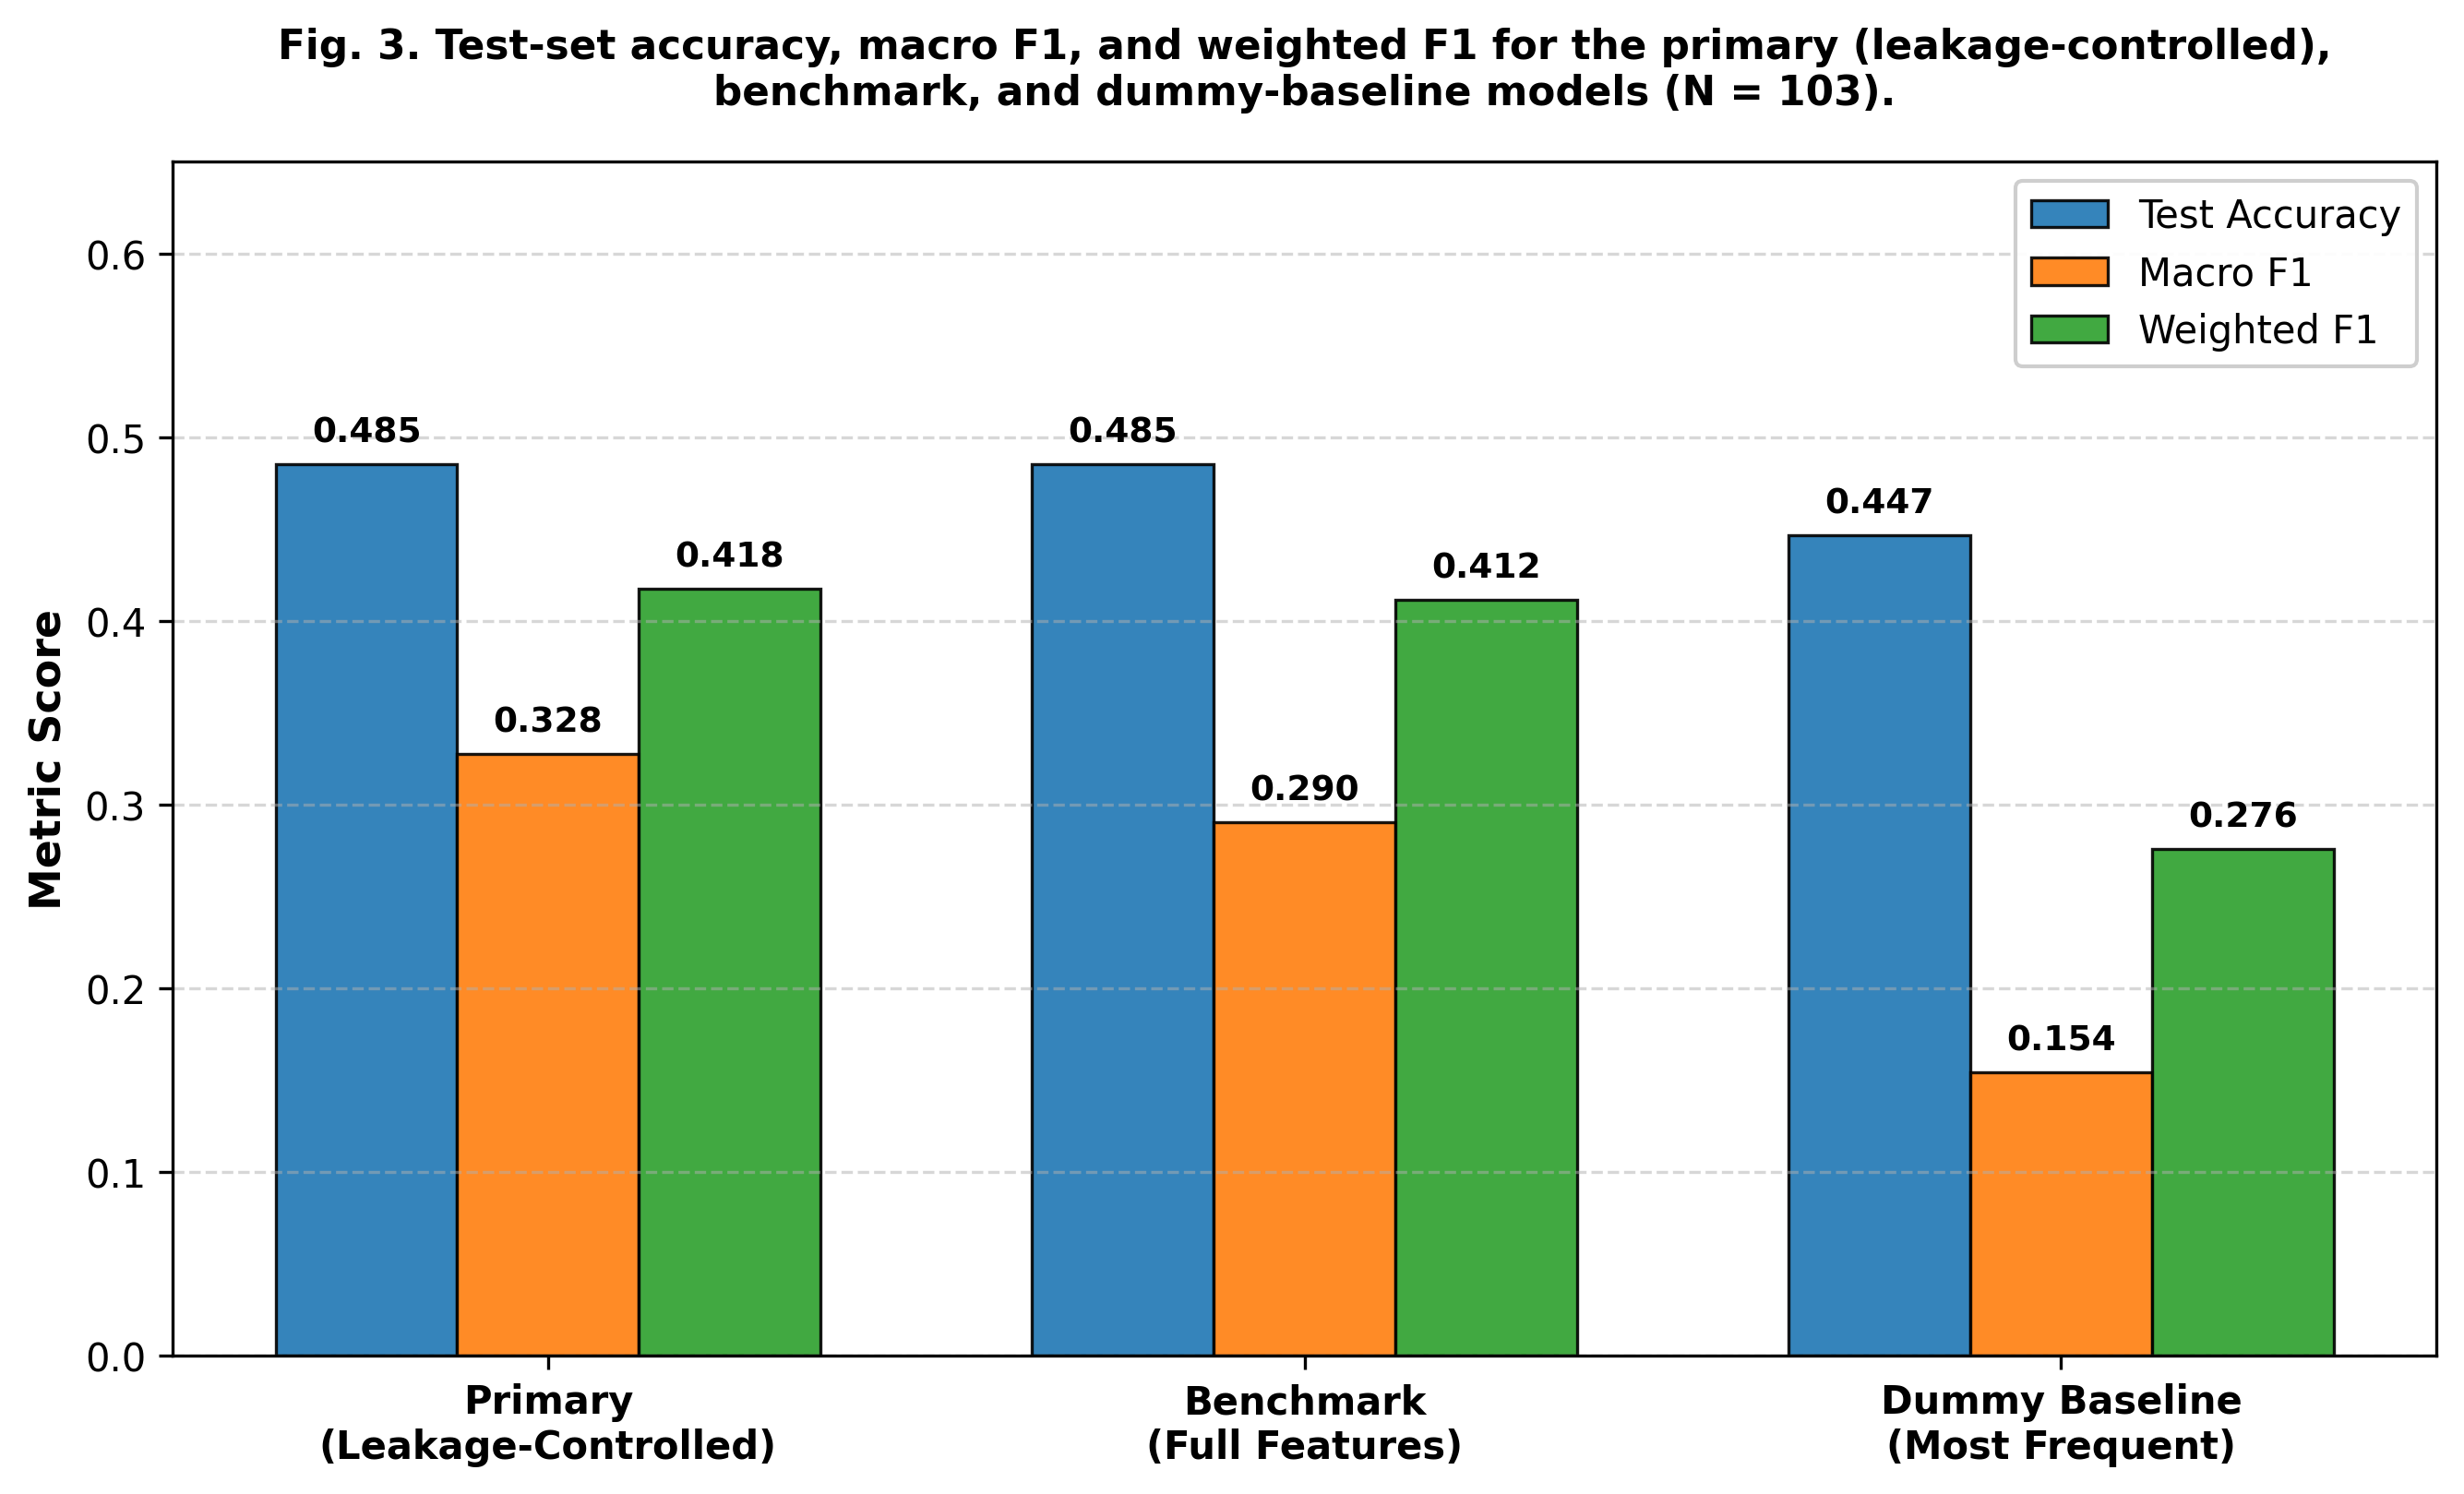

In [17]:
# ==============================================================================
# RESEARCH PAPER EVALUATION: MODEL COMPARISON (FIG. 3)
# Note: Strictly additive research analysis. Reuses existing held-out test set
# (N = 103) and existing models (rf_b, rf_a, dummy) without altering production code.
# ==============================================================================

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Reuse existing test-set ground truth labels and predictions (N = 103)
# Existing variables: y_test, y_pred_b (Primary), y_pred_a (Benchmark), y_pred_dummy (Baseline)
# Existing models: rf_b, rf_a, dummy with features X_test_b, X_test_a
try:
    pred_primary = y_pred_b
except NameError:
    pred_primary = rf_b.predict(X_test_b)

try:
    pred_benchmark = y_pred_a
except NameError:
    pred_benchmark = rf_a.predict(X_test_a)

try:
    pred_dummy = y_pred_dummy
except NameError:
    pred_dummy = dummy.predict(X_test_b)

# 2. Calculate Test-set Accuracy, Macro F1, and Weighted F1 (N = 103)
models_paper_eval = [
    {
        'Model': 'Primary model (leakage-controlled)',
        'Model_Label': 'Primary\n(Leakage-Controlled)',
        'Accuracy': float(accuracy_score(y_test, pred_primary)),
        'Macro_F1': float(f1_score(y_test, pred_primary, average='macro', zero_division=0)),
        'Weighted_F1': float(f1_score(y_test, pred_primary, average='weighted', zero_division=0))
    },
    {
        'Model': 'Benchmark model',
        'Model_Label': 'Benchmark\n(Full Features)',
        'Accuracy': float(accuracy_score(y_test, pred_benchmark)),
        'Macro_F1': float(f1_score(y_test, pred_benchmark, average='macro', zero_division=0)),
        'Weighted_F1': float(f1_score(y_test, pred_benchmark, average='weighted', zero_division=0))
    },
    {
        'Model': 'Dummy baseline',
        'Model_Label': 'Dummy Baseline\n(Most Frequent)',
        'Accuracy': float(accuracy_score(y_test, pred_dummy)),
        'Macro_F1': float(f1_score(y_test, pred_dummy, average='macro', zero_division=0)),
        'Weighted_F1': float(f1_score(y_test, pred_dummy, average='weighted', zero_division=0))
    }
]

df_fig3_metrics = pd.DataFrame(models_paper_eval)

# 3. Display Numerical Results Table
print("=" * 85)
print("RESEARCH PAPER RESULT: MODEL COMPARISON (N = 103 Test Records)")
print("=" * 85)
table_fig3 = df_fig3_metrics[['Model', 'Accuracy', 'Macro_F1', 'Weighted_F1']].copy()
table_fig3.columns = ['Model Evaluated', 'Test Accuracy', 'Macro F1', 'Weighted F1']
display(table_fig3.style.format({
    'Test Accuracy': '{:.4f}',
    'Macro F1': '{:.4f}',
    'Weighted F1': '{:.4f}'
}))

for idx, row in df_fig3_metrics.iterrows():
    print(f"{row['Model']:<35} | Accuracy: {row['Accuracy']:.4f} | Macro F1: {row['Macro_F1']:.4f} | Weighted F1: {row['Weighted_F1']:.4f}")
print("=" * 85)

# 4. Research-Paper-Quality Visualization (Fig. 3)
models_names = df_fig3_metrics['Model_Label'].tolist()
accuracy_vals = df_fig3_metrics['Accuracy'].tolist()
macro_f1_vals = df_fig3_metrics['Macro_F1'].tolist()
weighted_f1_vals = df_fig3_metrics['Weighted_F1'].tolist()

x = np.arange(len(models_names))
width = 0.24

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

rects1 = ax.bar(x - width, accuracy_vals, width, label='Test Accuracy', color='#1f77b4', edgecolor='black', linewidth=0.8, alpha=0.9)
rects2 = ax.bar(x, macro_f1_vals, width, label='Macro F1', color='#ff7f0e', edgecolor='black', linewidth=0.8, alpha=0.9)
rects3 = ax.bar(x + width, weighted_f1_vals, width, label='Weighted F1', color='#2ca02c', edgecolor='black', linewidth=0.8, alpha=0.9)

ax.set_ylabel('Metric Score', fontsize=11, fontweight='bold')
ax.set_title('Fig. 3. Test-set accuracy, macro F1, and weighted F1 for the primary (leakage-controlled),\nbenchmark, and dummy-baseline models (N = 103).', fontsize=10.5, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_names, fontsize=10, fontweight='bold')
ax.legend(frameon=True, facecolor='white', framealpha=0.95, edgecolor='#cccccc', fontsize=10, loc='upper right')
ax.set_ylim(0, 0.65)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


## Research Paper Analysis — 5-Fold Stratified Cross-Validation
This section conducts 5-fold stratified cross-validation on the training dataset ($N = 411$) to evaluate the generalization stability and variance across folds for the Primary (Leakage-Controlled) Model and Benchmark Model:

**Fig. 4. Mean 5-fold stratified cross-validation accuracy, weighted F1, and macro F1 for the primary and benchmark models, with error bars showing one standard deviation (N = 411 training records).**

> **Research Note:** Cross-validation is performed strictly on the training partition ($N = 411$) to prevent data snooping. Evaluated via independent temporary cross-validation runs to guarantee that the final trained production model is not modified.

RESEARCH PAPER RESULT: 5-FOLD STRATIFIED CROSS-VALIDATION (N = 411 Training Records)


,Evaluated Model,Mean Accuracy ± SD,Mean Weighted F1 ± SD,Mean Macro F1 ± SD
0,Primary model (leakage-controlled),0.4988 ± 0.0174,0.4387 ± 0.0226,0.3461 ± 0.0489
1,Benchmark model,0.4867 ± 0.0289,0.4254 ± 0.0217,0.3188 ± 0.0318



Primary model (leakage-controlled):
  Mean Accuracy   : 0.4988 ± 0.0174
  Mean Weighted F1: 0.4387 ± 0.0226
  Mean Macro F1   : 0.3461 ± 0.0489

Benchmark model:
  Mean Accuracy   : 0.4867 ± 0.0289
  Mean Weighted F1: 0.4254 ± 0.0217
  Mean Macro F1   : 0.3188 ± 0.0318


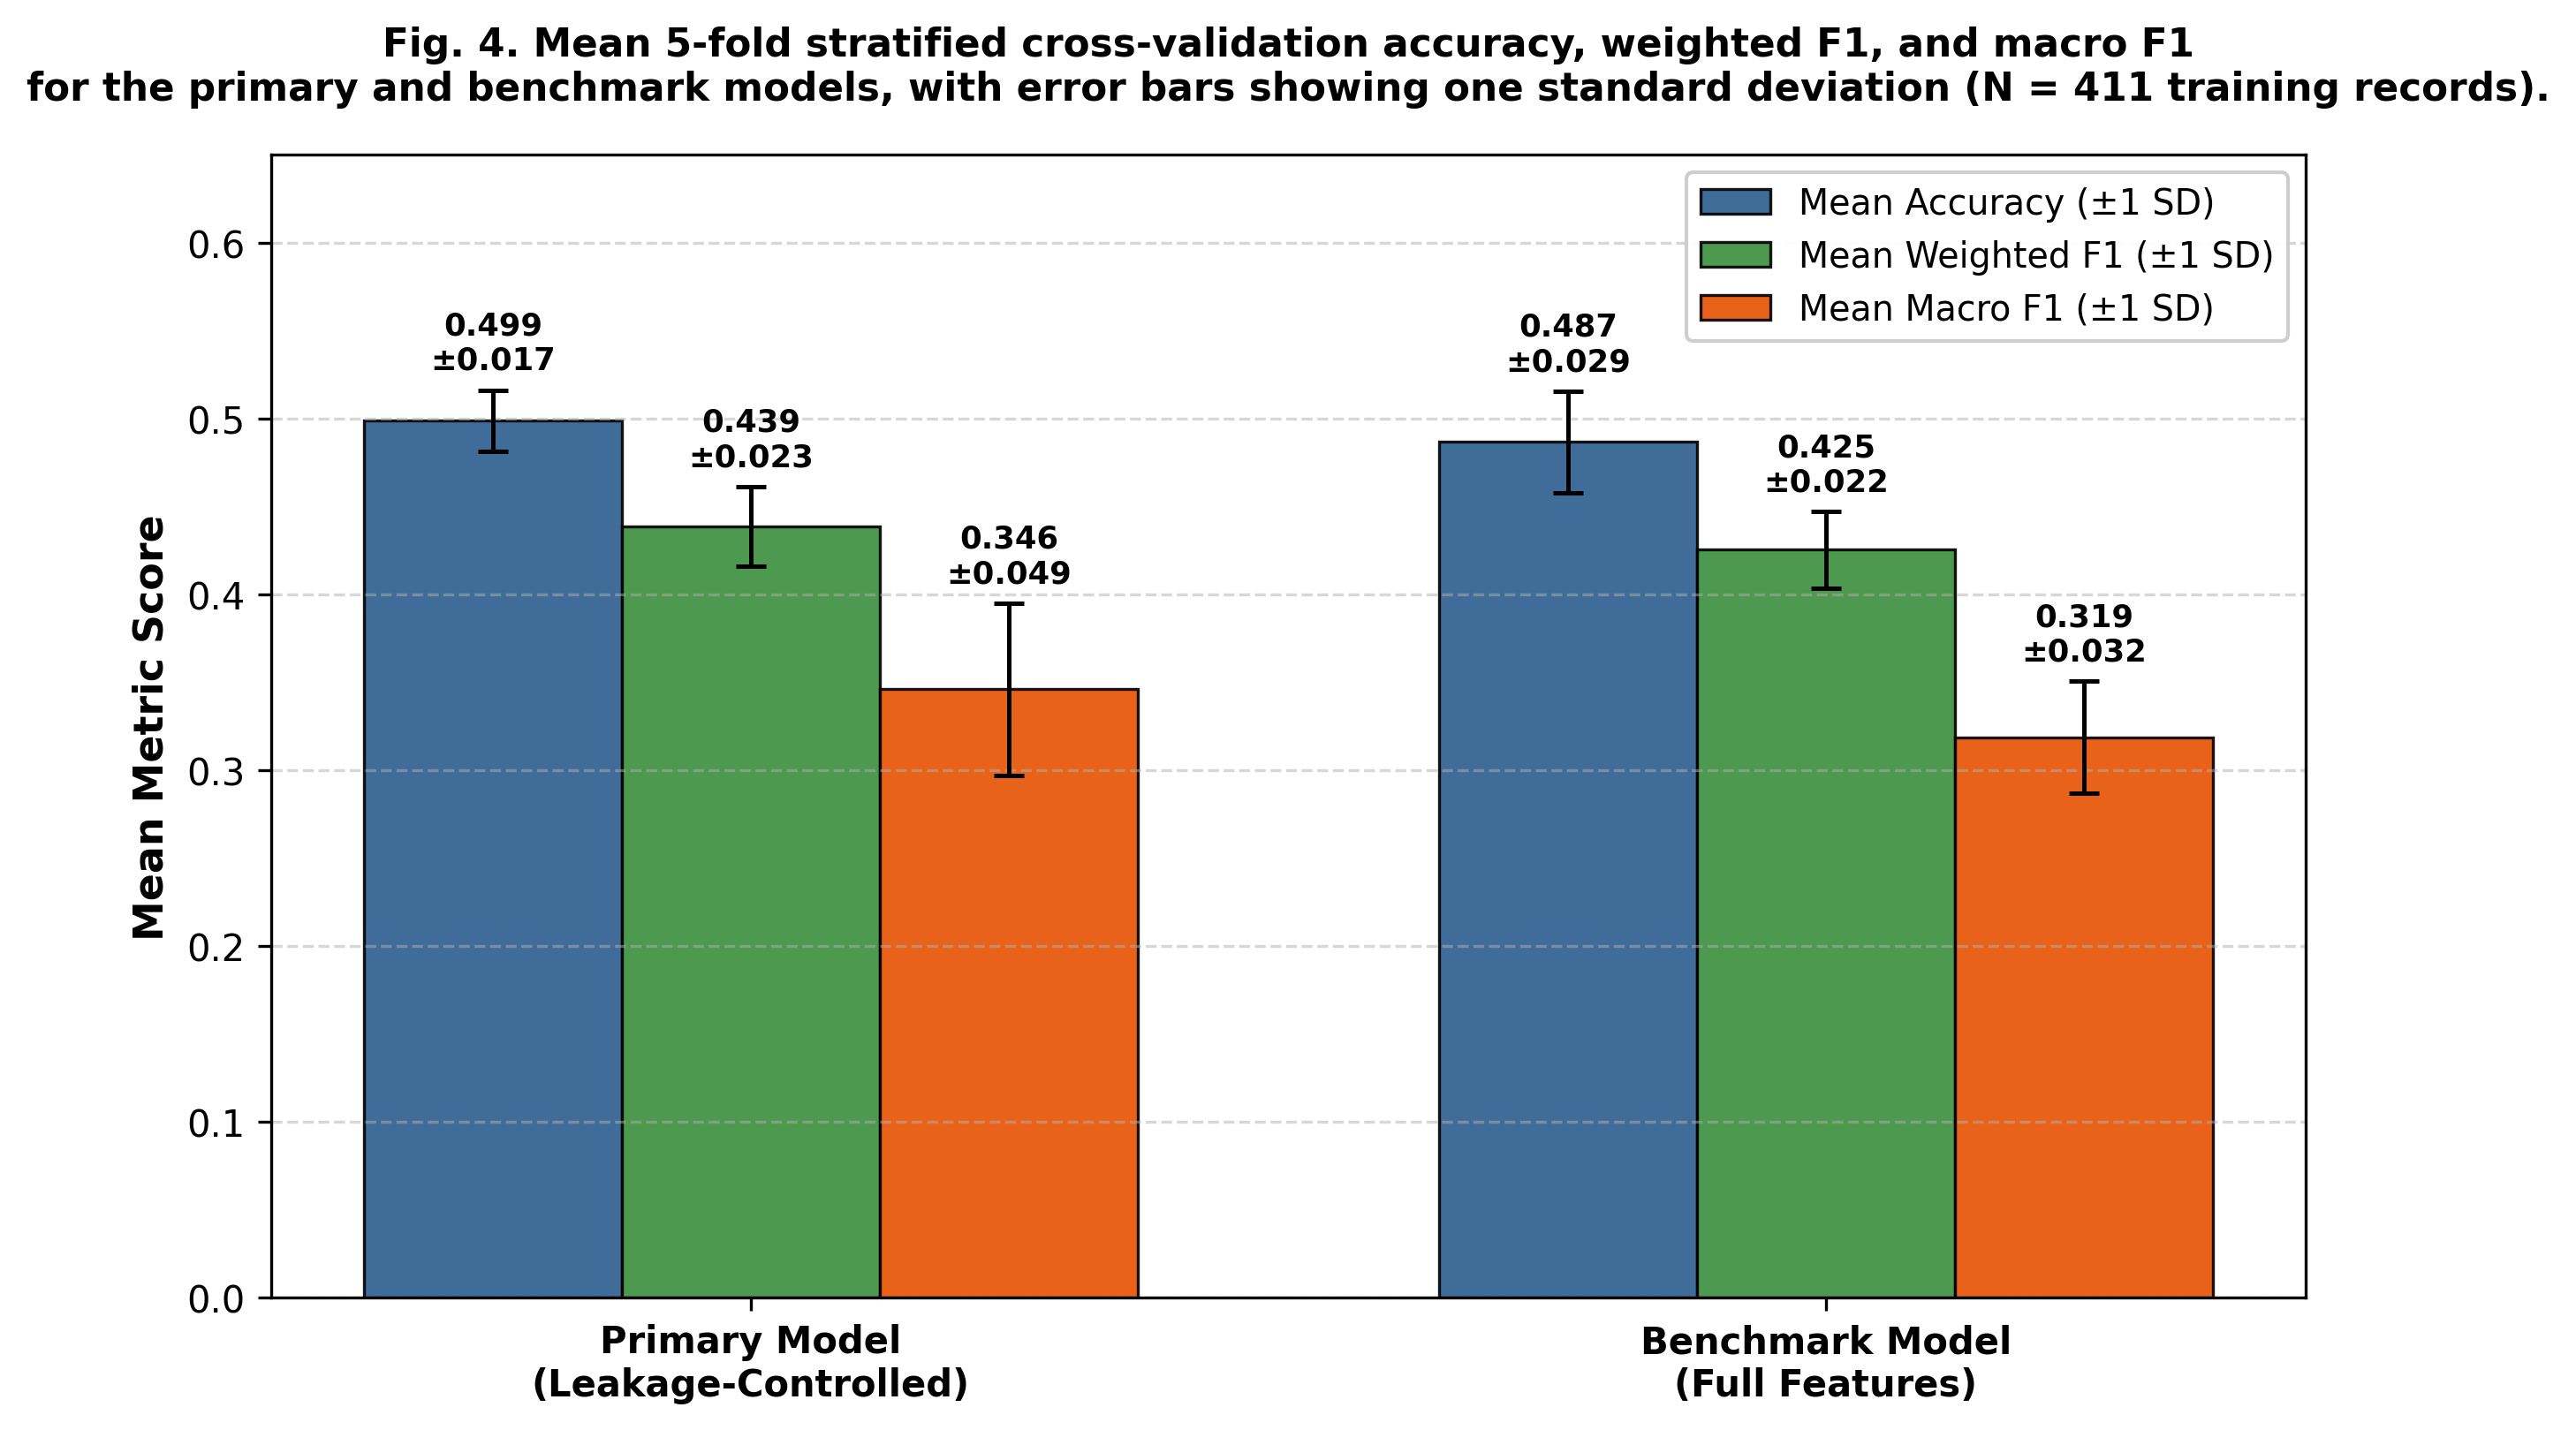

In [18]:
# ==============================================================================
# RESEARCH PAPER EVALUATION: 5-FOLD STRATIFIED CROSS-VALIDATION (FIG. 4)
# Note: Strictly additive research analysis on training records (N = 411).
# Evaluates generalization mean ± standard deviation without altering production models.
# ==============================================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 5-Fold Stratified Cross-Validation Setup on N = 411 training records
# Reuses existing cross_validate outputs from Cell 14 (cv_b, cv_a) or calculates
# on existing training features and targets (X_train_b, X_train_a, y_train)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

try:
    res_cv_b = cv_b
except NameError:
    # Evaluate temporary estimator using existing training dataset X_train_b, y_train
    temp_rf_b = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    res_cv_b = cross_validate(temp_rf_b, X_train_b, y_train, cv=cv_stratified, scoring=['accuracy', 'f1_weighted', 'f1_macro'])

try:
    res_cv_a = cv_a
except NameError:
    # Evaluate temporary estimator using existing training dataset X_train_a, y_train
    temp_rf_a = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    res_cv_a = cross_validate(temp_rf_a, X_train_a, y_train, cv=cv_stratified, scoring=['accuracy', 'f1_weighted', 'f1_macro'])

# 2. Calculate Mean and Standard Deviation across the 5 folds
cv_summary_data = [
    {
        'Model': 'Primary model (leakage-controlled)',
        'Model_Label': 'Primary Model\n(Leakage-Controlled)',
        'Mean_Accuracy': float(res_cv_b['test_accuracy'].mean()),
        'Std_Accuracy': float(res_cv_b['test_accuracy'].std()),
        'Mean_Weighted_F1': float(res_cv_b['test_f1_weighted'].mean()),
        'Std_Weighted_F1': float(res_cv_b['test_f1_weighted'].std()),
        'Mean_Macro_F1': float(res_cv_b['test_f1_macro'].mean()),
        'Std_Macro_F1': float(res_cv_b['test_f1_macro'].std()),
    },
    {
        'Model': 'Benchmark model',
        'Model_Label': 'Benchmark Model\n(Full Features)',
        'Mean_Accuracy': float(res_cv_a['test_accuracy'].mean()),
        'Std_Accuracy': float(res_cv_a['test_accuracy'].std()),
        'Mean_Weighted_F1': float(res_cv_a['test_f1_weighted'].mean()),
        'Std_Weighted_F1': float(res_cv_a['test_f1_weighted'].std()),
        'Mean_Macro_F1': float(res_cv_a['test_f1_macro'].mean()),
        'Std_Macro_F1': float(res_cv_a['test_f1_macro'].std()),
    }
]

df_cv_summary = pd.DataFrame(cv_summary_data)

# 3. Display Numerical Results Table (Mean ± SD)
print("=" * 90)
print("RESEARCH PAPER RESULT: 5-FOLD STRATIFIED CROSS-VALIDATION (N = 411 Training Records)")
print("=" * 90)
table_fig4 = pd.DataFrame([
    {
        'Evaluated Model': item['Model'],
        'Mean Accuracy ± SD': f"{item['Mean_Accuracy']:.4f} ± {item['Std_Accuracy']:.4f}",
        'Mean Weighted F1 ± SD': f"{item['Mean_Weighted_F1']:.4f} ± {item['Std_Weighted_F1']:.4f}",
        'Mean Macro F1 ± SD': f"{item['Mean_Macro_F1']:.4f} ± {item['Std_Macro_F1']:.4f}"
    }
    for item in cv_summary_data
])
display(table_fig4)

for item in cv_summary_data:
    print(f"\n{item['Model']}:")
    print(f"  Mean Accuracy   : {item['Mean_Accuracy']:.4f} ± {item['Std_Accuracy']:.4f}")
    print(f"  Mean Weighted F1: {item['Mean_Weighted_F1']:.4f} ± {item['Std_Weighted_F1']:.4f}")
    print(f"  Mean Macro F1   : {item['Mean_Macro_F1']:.4f} ± {item['Std_Macro_F1']:.4f}")
print("=" * 90)

# 4. Research-Paper-Quality Visualization with Error Bars (Fig. 4)
fig4_models = df_cv_summary['Model_Label'].tolist()
means_acc = df_cv_summary['Mean_Accuracy'].tolist()
stds_acc = df_cv_summary['Std_Accuracy'].tolist()

means_wf1 = df_cv_summary['Mean_Weighted_F1'].tolist()
stds_wf1 = df_cv_summary['Std_Weighted_F1'].tolist()

means_mf1 = df_cv_summary['Mean_Macro_F1'].tolist()
stds_mf1 = df_cv_summary['Std_Macro_F1'].tolist()

x_cv_pos = np.arange(len(fig4_models))
w_cv_bar = 0.24

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=300)

r1 = ax.bar(x_cv_pos - w_cv_bar, means_acc, w_cv_bar, yerr=stds_acc, capsize=4,
            label='Mean Accuracy (±1 SD)', color='#2b5c8f', edgecolor='black', linewidth=0.8, alpha=0.9,
            error_kw=dict(lw=1.2, capthick=1.2, ecolor='black'))

r2 = ax.bar(x_cv_pos, means_wf1, w_cv_bar, yerr=stds_wf1, capsize=4,
            label='Mean Weighted F1 (±1 SD)', color='#388e3c', edgecolor='black', linewidth=0.8, alpha=0.9,
            error_kw=dict(lw=1.2, capthick=1.2, ecolor='black'))

r3 = ax.bar(x_cv_pos + w_cv_bar, means_mf1, w_cv_bar, yerr=stds_mf1, capsize=4,
            label='Mean Macro F1 (±1 SD)', color='#e65100', edgecolor='black', linewidth=0.8, alpha=0.9,
            error_kw=dict(lw=1.2, capthick=1.2, ecolor='black'))

ax.set_ylabel('Mean Metric Score', fontsize=11, fontweight='bold')
ax.set_title('Fig. 4. Mean 5-fold stratified cross-validation accuracy, weighted F1, and macro F1\nfor the primary and benchmark models, with error bars showing one standard deviation (N = 411 training records).',
             fontsize=10.5, fontweight='bold', pad=15)
ax.set_xticks(x_cv_pos)
ax.set_xticklabels(fig4_models, fontsize=10, fontweight='bold')
ax.legend(frameon=True, facecolor='white', framealpha=0.95, edgecolor='#cccccc', fontsize=9.5, loc='upper right')
ax.set_ylim(0, 0.65)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel_cv_bars(rects, stds):
    for rect, s in zip(rects, stds):
        h = rect.get_height()
        ax.annotate(f'{h:.3f}\n±{s:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h + s),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

autolabel_cv_bars(r1, stds_acc)
autolabel_cv_bars(r2, stds_wf1)
autolabel_cv_bars(r3, stds_mf1)

plt.tight_layout()
plt.show()
